## CMPINF 2100 Week 09
### Introduction to Regression: Assumptions of the linear model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## Regression

We will begin with the LINEAR MODEL. You commonly hear this described as LINEAR REGRESSION

The goal of regression is to predict a CONTINUOUS OUTPUT **GIVEN** INPUTS

For now, we will start simple with a SINGLE continuous input

The Regression model is BETWEEN the INPUT AND OUTPUT... I typically describe the relationship DIFFERENTLY

I like to be SPECIFIC about where the MODEL is actually applied!!!

The model does **NOT** predict the OUTPUT

The model predicts the **AVERAGE** or **MEAN** output!!

The AVERAGE OUTPUT depends on the INPUT!!!

The math notation:

$$\mu = \beta_0 + \beta_1 \times x $$

### Visualize the trend vs the input

To do this we need to CREATE our own data

I like to SEE the assumptions of the LINEAR MODEL by GENERATING our own data!!!

Create a DataFrame that contains a SINGLE continuous input, `x` between -3.5 and 3.5

In [3]:
df_viz = pd.DataFrame({'x': np.linspace(-3.5, 3.5, num=101)})

In [4]:
df_viz

,x
0,-3.50
1,-3.43
2,-3.36
3,-3.29
4,-3.22
...,...
96,3.22
97,3.29
98,3.36
99,3.43


To calculate the TREND or the AVERAGE OUTPOUT we need to KNOW the coefficients, the INTERCEPT and SLOPE of the model!!!

In [153]:
my_intercept = 0.25
my_slope = -1.5

In [154]:
df_viz['trend'] = my_intercept + my_slope * df_viz.x

In [155]:
df_viz

,x,trend
0,-3.50,5.500
1,-3.43,5.395
2,-3.36,5.290
3,-3.29,5.185
4,-3.22,5.080
...,...,...
96,3.22,-4.580
97,3.29,-4.685
98,3.36,-4.790
99,3.43,-4.895


Visualize the relationship in Seaborn using a LINE CHART

In [156]:
sns.set_style('whitegrid')

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


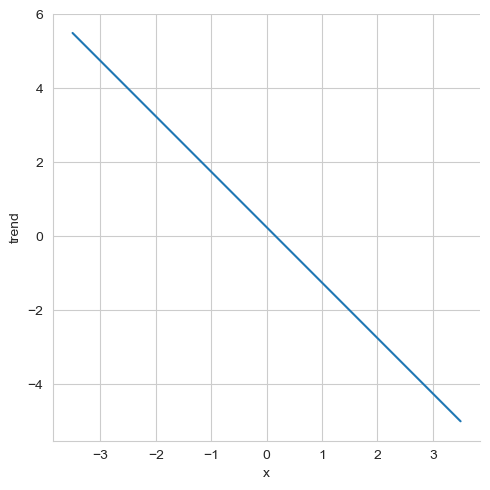

In [157]:
sns.relplot(data = df_viz, x='x', y='trend', kind='line')
plt.show()

### Randomness

The coplete story of a linear model involves RANDOMNESS!!!

Upto this point I have referred to the MODEL as BETWEEN the AVERAGE OUTPUT or TREND and the INPUT!!!

The OBSERVED OUTPUT is **RANDOMLY** distributed around the AVERAGE OUTPUT!!!

The OBSERVED OUTPUT is **NORMALLY** distributed around the AVERAGE OUTPUT!!!

The RANDOMNESS represents that there is a LIKELYHOOD between the OBSERVED OUTPUT and the TREND!!!

We will SIMULATE random outputs around the TREND.

We therefore need to set the seed to ensure reproducibility!!!

In [158]:
rg = np.random.default_rng(2100)

Let's create a smaller data set to help visualize randomness.

These data set will have 9 unique valus of the input between -3 and 3

In [159]:
df = pd.DataFrame({'x': np.linspace(-3, 3, num=9)})

In [160]:
df

,x
0,-3.00
1,-2.25
2,-1.50
3,-0.75
4,0.00
5,0.75
6,1.50
7,2.25
8,3.00


Calculate the trend

In [161]:
df['trend'] = my_intercept + my_slope * df.x

In [162]:
df

,x,trend
0,-3.00,4.750
1,-2.25,3.625
2,-1.50,2.500
3,-0.75,1.375
4,0.00,0.250
5,0.75,-0.875
6,1.50,-2.000
7,2.25,-3.125
8,3.00,-4.250


the randomness comes into play due to the OUTPUT around the TREND!!!

We must set the STANDARD DEVIATION in our Gaussian LIKELIHOOD

In [163]:
sigma_noise = 1.25

In [164]:
df['y'] = rg.normal(loc = df.trend.to_numpy(), scale=sigma_noise, size=df.shape[0])

In [165]:
df

,x,trend,y
0,-3.00,4.750,6.030315
1,-2.25,3.625,1.457911
2,-1.50,2.500,2.388383
3,-0.75,1.375,0.007815
4,0.00,0.250,0.651244
5,0.75,-0.875,-2.254007
6,1.50,-2.000,-2.969992
7,2.25,-3.125,-3.537097
8,3.00,-4.250,-6.063282


Plot the random OUTPUT vs the INPUT via a scatter plot

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


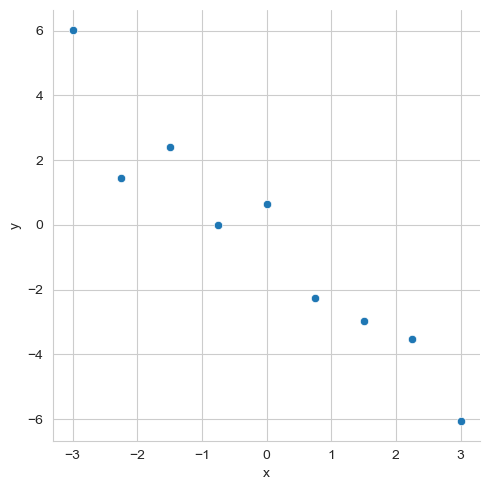

In [166]:
sns.relplot(data = df, x='x', y='y', kind='scatter')
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


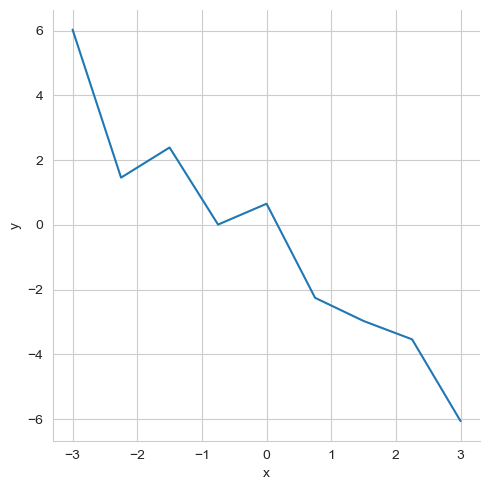

In [167]:
sns.relplot(data = df, x='x', y='y', kind='line')
plt.show()

Create a composite figure to show the observed random outputs around the TREND

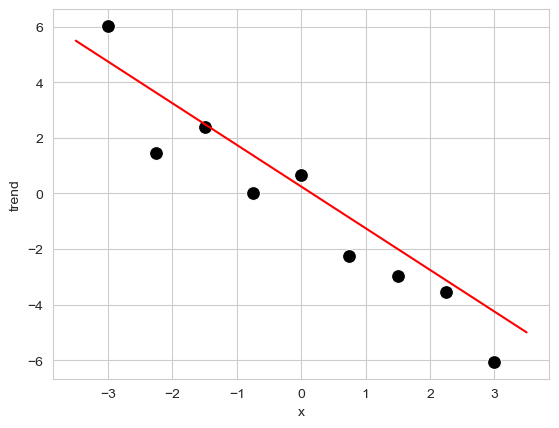

In [168]:
fig, ax = plt.subplots()

sns.lineplot(data = df_viz, x='x', y='trend', color='red', ax=ax)

sns.scatterplot(data = df, x='x', y='y', s=100, color='k', ax=ax)

plt.show()

What happens if we RANDOMLY generate MORE observations

What if we **REPLICATE** calling the random number generator more time!!!

In [169]:
df_try = df.copy()

In [170]:
df_try

,x,trend,y
0,-3.00,4.750,6.030315
1,-2.25,3.625,1.457911
2,-1.50,2.500,2.388383
3,-0.75,1.375,0.007815
4,0.00,0.250,0.651244
5,0.75,-0.875,-2.254007
6,1.50,-2.000,-2.969992
7,2.25,-3.125,-3.537097
8,3.00,-4.250,-6.063282


Let's ADD 2 new columns where we call the random number generator 2 more times

In [171]:
df_try['y1'] = rg.normal(loc=df.trend.to_numpy(), scale=sigma_noise, size=df.shape[0])

In [172]:
df_try['y2'] = rg.normal(loc=df.trend.to_numpy(), scale=sigma_noise, size=df.shape[0])

In [173]:
df_try

,x,trend,y,y1,y2
0,-3.00,4.750,6.030315,6.086360,5.679270
1,-2.25,3.625,1.457911,3.371986,3.969865
2,-1.50,2.500,2.388383,0.892498,4.722336
3,-0.75,1.375,0.007815,1.134130,2.508582
4,0.00,0.250,0.651244,-1.273273,0.013304
5,0.75,-0.875,-2.254007,-0.667254,-0.392712
6,1.50,-2.000,-2.969992,-1.243836,-2.302036
7,2.25,-3.125,-3.537097,-0.847057,-2.839094
8,3.00,-4.250,-6.063282,-5.543591,-3.490245


Visualize the 3 sets of randomly  generated outputs together

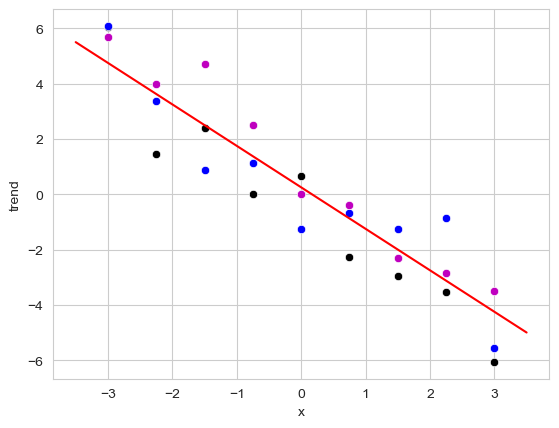

In [177]:
fig, ax = plt.subplots()

sns.lineplot(data = df_viz, x='x', y='trend', color='red', ax=ax)

sns.scatterplot(data = df_try, x='x', y='y', color='k', ax=ax)
sns.scatterplot(data = df_try, x='x', y='y1', color='b', ax=ax)
sns.scatterplot(data = df_try, x='x', y='y2', color='m', ax=ax)

plt.show()

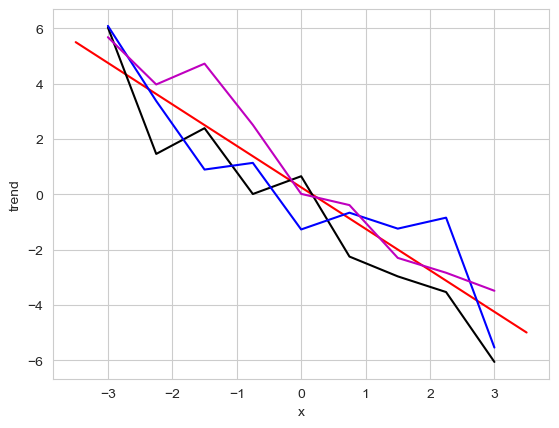

In [178]:
fig, ax = plt.subplots()

sns.lineplot(data = df_viz, x='x', y='trend', color='red', ax=ax)

sns.lineplot(data = df_try, x='x', y='y', color='k', ax=ax)
sns.lineplot(data = df_try, x='x', y='y1', color='b', ax=ax)
sns.lineplot(data = df_try, x='x', y='y2', color='m', ax=ax)

plt.show()

What if we could REPLICATE many, many many times???

How will the random observations be DISTRIBUTED around the **TRUE** trend???

Define a function which calculates the trend for a given set of INTERCEPT and SLOPE and then GENERATES random ouputs around the trend for a given standard deviation

In [181]:
def generate_lm_y(rid, xuse, b0, b1, sigma_use):
    res_df = pd.DataFrame({'x': xuse})
    res_df['trend'] = b0 + b1 * res_df.x
    res_df['y'] = rg.normal(loc=res_df.trend.to_numpy(),
                            scale=sigma_use,
                            size=res_df.shape[0])
    res_df['rep_id'] = rid
    return res_df

In [182]:
generate_lm_y(0, df.x, my_intercept, my_slope, sigma_noise)

,x,trend,y,rep_id
0,-3.00,4.750,4.298194,0
1,-2.25,3.625,5.347201,0
2,-1.50,2.500,4.072299,0
3,-0.75,1.375,3.191032,0
4,0.00,0.250,-1.379291,0
5,0.75,-0.875,-0.534659,0
6,1.50,-2.000,-3.312908,0
7,2.25,-3.125,-3.921768,0
8,3.00,-4.250,-5.063279,0


Let's replicate 4 times

In [183]:
study_4_list = []

for ix in range(4):
    study_4_list.append( generate_lm_y(ix, df.x,
                                      my_intercept, my_slope,
                                      sigma_noise))

In [184]:
len(study_4_list)

4

In [185]:
study_4_list[0]

,x,trend,y,rep_id
0,-3.00,4.750,5.992379,0
1,-2.25,3.625,3.939756,0
2,-1.50,2.500,4.195678,0
3,-0.75,1.375,1.193599,0
4,0.00,0.250,1.567933,0
5,0.75,-0.875,-2.912425,0
6,1.50,-2.000,-2.489533,0
7,2.25,-3.125,0.048199,0
8,3.00,-4.250,-4.501993,0


In [186]:
study_4_list[1]

,x,trend,y,rep_id
0,-3.00,4.750,4.843531,1
1,-2.25,3.625,2.484161,1
2,-1.50,2.500,0.854287,1
3,-0.75,1.375,2.145425,1
4,0.00,0.250,0.913213,1
5,0.75,-0.875,-0.832066,1
6,1.50,-2.000,-0.296928,1
7,2.25,-3.125,-1.948809,1
8,3.00,-4.250,-4.673369,1


Veritcally STACK or combine the dataframes in the list

In [187]:
study_4_df = pd.concat( study_4_list, ignore_index=True )

In [188]:
study_4_df

,x,trend,y,rep_id
0,-3.00,4.750,5.992379,0
1,-2.25,3.625,3.939756,0
2,-1.50,2.500,4.195678,0
3,-0.75,1.375,1.193599,0
4,0.00,0.250,1.567933,0
5,0.75,-0.875,-2.912425,0
6,1.50,-2.000,-2.489533,0
7,2.25,-3.125,0.048199,0
8,3.00,-4.250,-4.501993,0
9,-3.00,4.750,4.843531,1


Visualize the 4 random replications!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


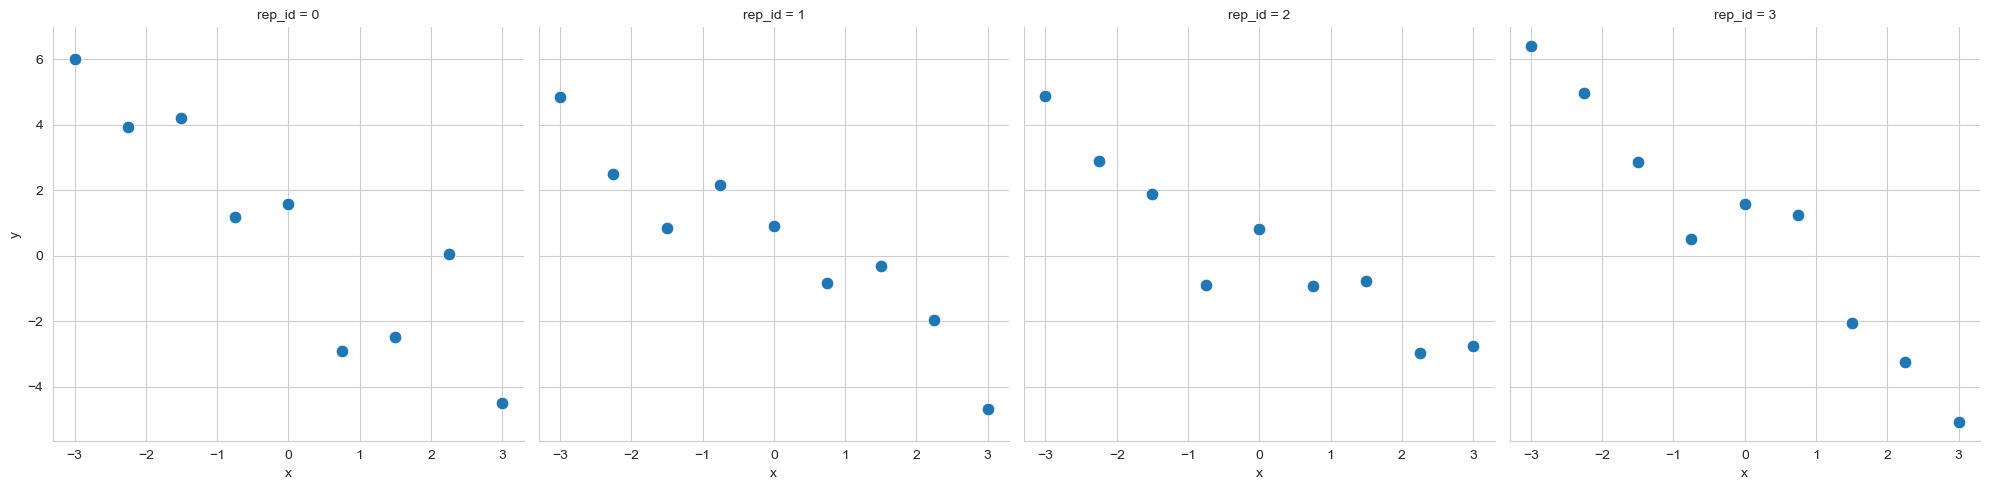

In [190]:
sns.relplot(data = study_4_df, x='x', y='y', col='rep_id', s=85)
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


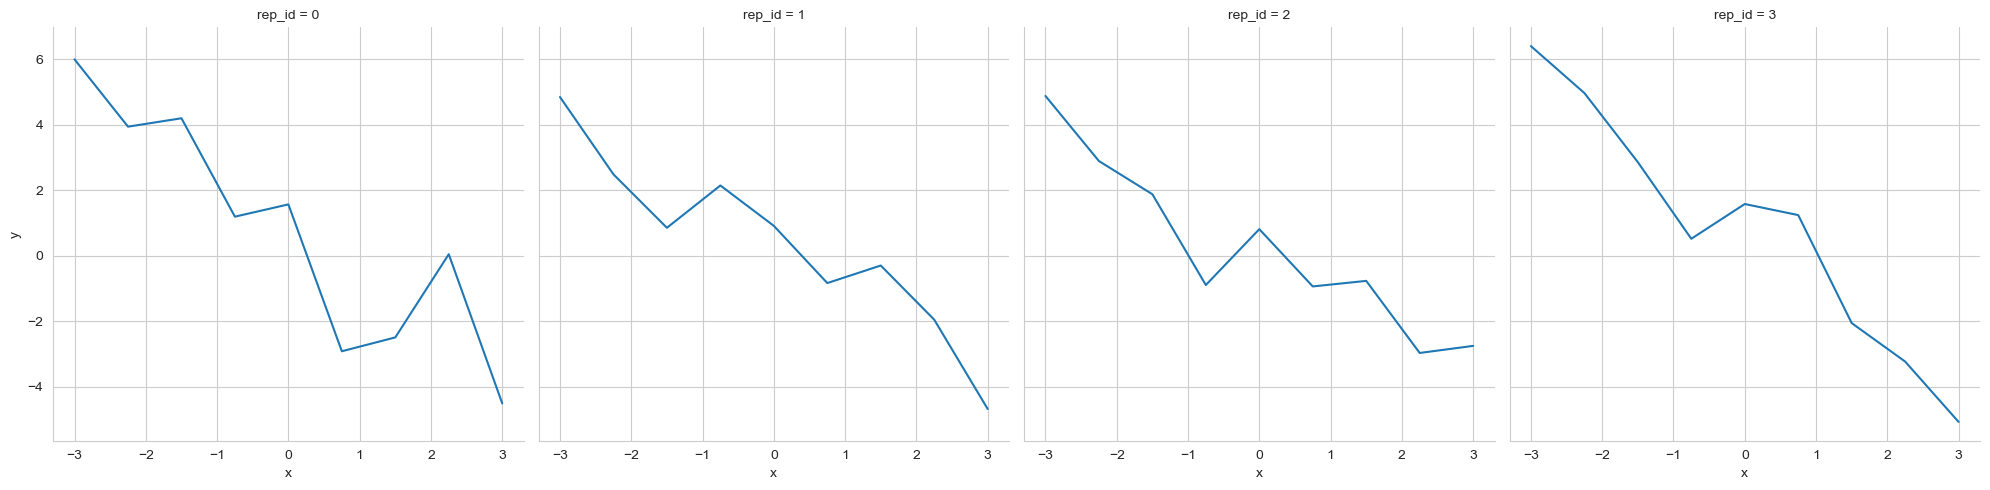

In [191]:
sns.relplot(data = study_4_df, x='x', y='y', col='rep_id', kind='line')
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


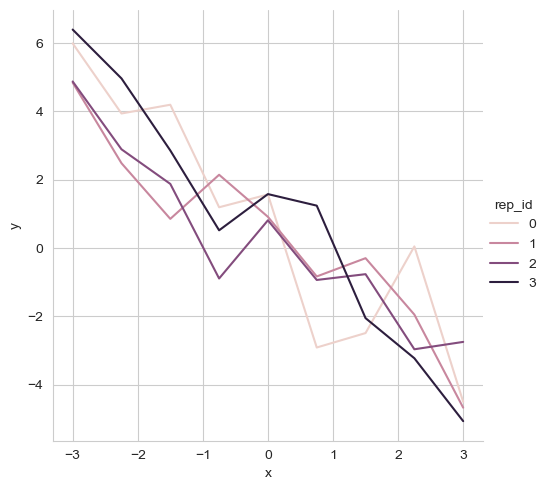

In [192]:
sns.relplot(data = study_4_df, x='x', y='y', hue='rep_id', kind='line')
plt.show()

But...what we really care about...is the **AVERAGE** output!!

How is the **AVERAGE** changing as the INPUT changes??

Let's calculate the AVERAGE output for each unique value of the imput!!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


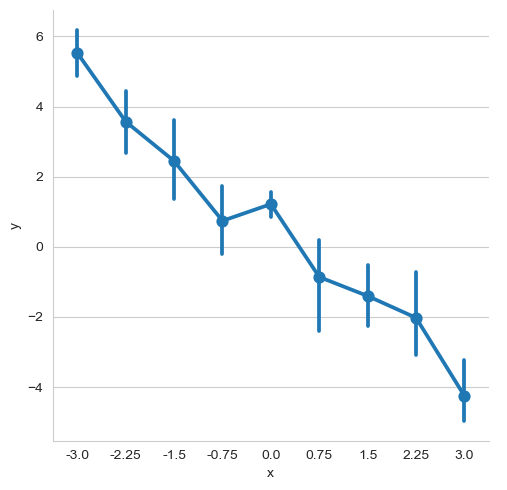

In [193]:
sns.catplot(data = study_4_df, x='x', y='y', kind='point')
plt.show()

we could create this kind of figure with the `sns.lmplot`

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


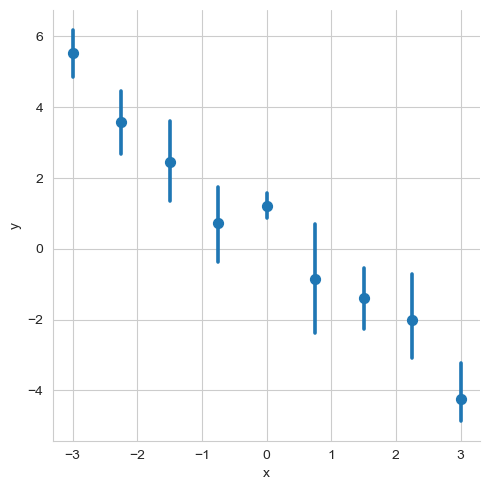

In [195]:
sns.lmplot(data = study_4_df, x='x', y='y', fit_reg=False, x_estimator=np.mean)
plt.show()

What if we used 20 replications instead of 4???

In [196]:
study_20_list = []

for ix in range(20):
    study_20_list.append( generate_lm_y(ix, df.x,
                                      my_intercept, my_slope,
                                      sigma_noise))

In [197]:
len( study_20_list)

20

In [198]:
study_20_df = pd.concat( study_20_list, ignore_index=True)

In [199]:
study_20_df

,x,trend,y,rep_id
0,-3.00,4.750,5.141063,0
1,-2.25,3.625,2.915319,0
2,-1.50,2.500,1.132301,0
3,-0.75,1.375,2.224567,0
4,0.00,0.250,0.789303,0
...,...,...,...,...
175,0.00,0.250,-1.401143,19
176,0.75,-0.875,1.080615,19
177,1.50,-2.000,-3.667466,19
178,2.25,-3.125,-2.715605,19


/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


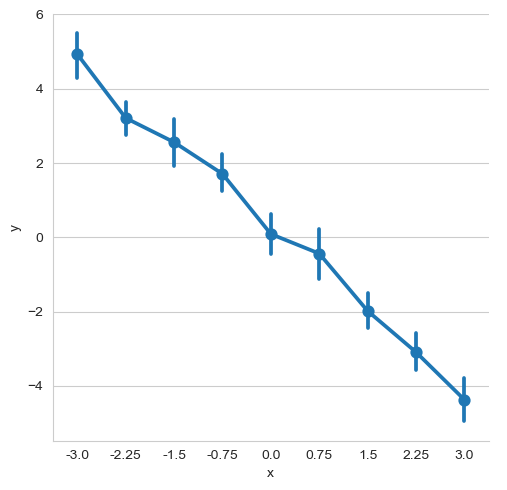

In [200]:
sns.catplot(data = study_20_df, x='x', y='y', kind='point')
plt.show()

Replicate with 500 times!!!

In [201]:
study_500_list = []

for ix in range(500):
    study_500_list.append( generate_lm_y(ix, df.x,
                                      my_intercept, my_slope,
                                      sigma_noise))

In [202]:
study_500_df = pd.concat( study_500_list, ignore_index=True)

In [203]:
study_500_df

,x,trend,y,rep_id
0,-3.00,4.750,5.566755,0
1,-2.25,3.625,2.791843,0
2,-1.50,2.500,2.759388,0
3,-0.75,1.375,-0.325395,0
4,0.00,0.250,-0.345538,0
...,...,...,...,...
4495,0.00,0.250,0.369784,499
4496,0.75,-0.875,0.232438,499
4497,1.50,-2.000,-1.873576,499
4498,2.25,-3.125,-0.405102,499


/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


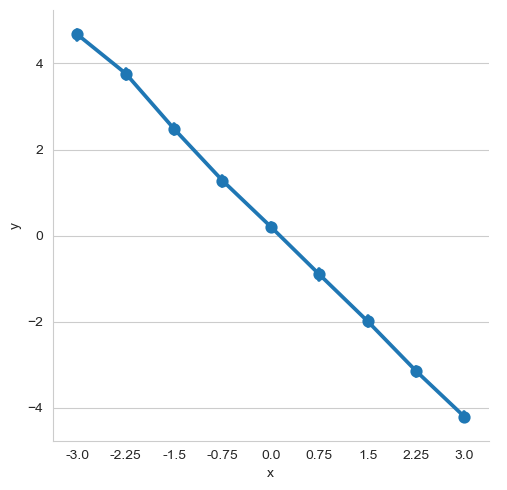

In [204]:
sns.catplot(data = study_500_df, x='x', y='y', kind='point')
plt.show()

In [205]:
study_5000_list = []

for ix in range(5000):
    study_5000_list.append( generate_lm_y(ix, df.x,
                                      my_intercept, my_slope,
                                      sigma_noise))

In [206]:
study_5000_df = pd.concat( study_5000_list, ignore_index=True)

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


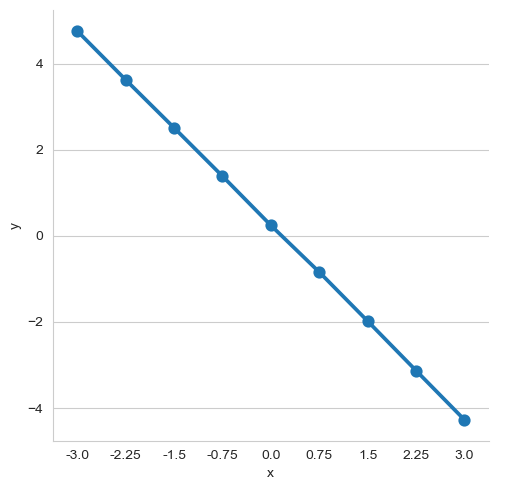

In [207]:
sns.catplot(data = study_5000_df, x='x', y='y', kind='point')
plt.show()

Plot the OBSERVATIONS from the 500 replications on top of the trtue trend and the smaple average at each input

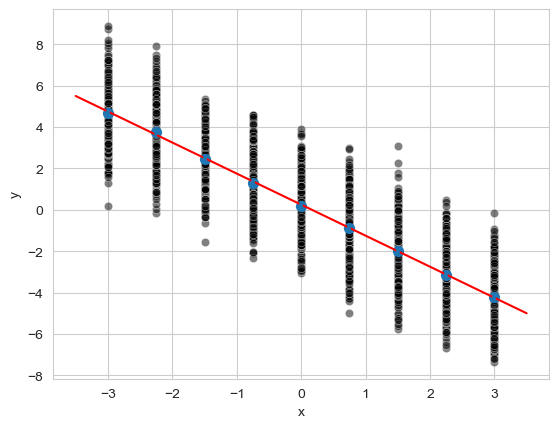

In [209]:
fig, ax = plt.subplots()

sns.scatterplot( data = study_500_df, x='x', y='y', alpha=0.5, color='k', ax=ax)

sns.lineplot( data = df_viz, x='x', y='trend', color='r', ax=ax)

sns.regplot( data = study_500_df, x='x', y='y', fit_reg=False, x_estimator=np.mean, ax=ax)

plt.show()


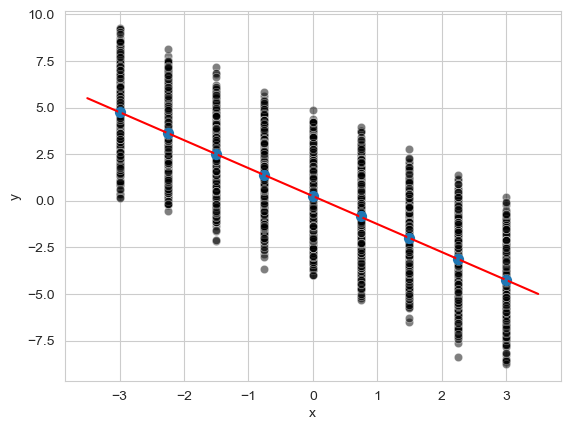

In [210]:
fig, ax = plt.subplots()

sns.scatterplot( data = study_5000_df, x='x', y='y', alpha=0.5, color='k', ax=ax)

sns.lineplot( data = df_viz, x='x', y='trend', color='r', ax=ax)

sns.regplot( data = study_5000_df, x='x', y='y', fit_reg=False, x_estimator=np.mean, ax=ax)

plt.show()


Let's look at the VARIATION around the TRUE TREND in more detail via BOXPLOTS

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


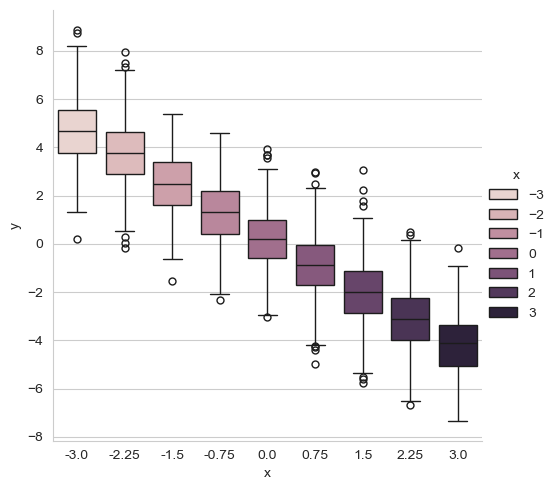

In [212]:
sns.catplot( data = study_500_df, x='x', y='y', kind='box', hue='x')
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


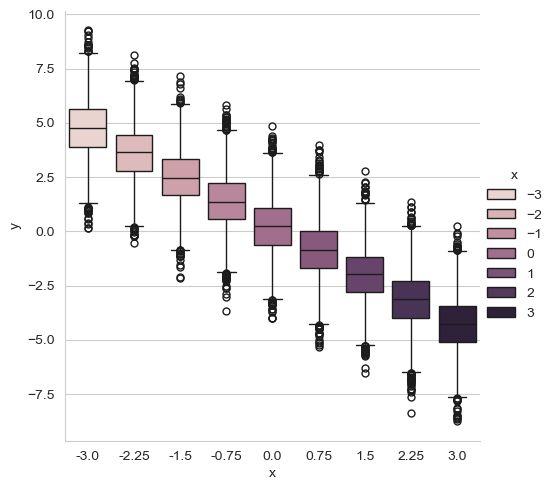

In [213]:
sns.catplot( data = study_5000_df, x='x', y='y', kind='box', hue='x')
plt.show()

Boxplots do not show the distributional SHAPE of the data

Let's look at the distributional shape of the 500 replications at each input location using VIOLINS

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


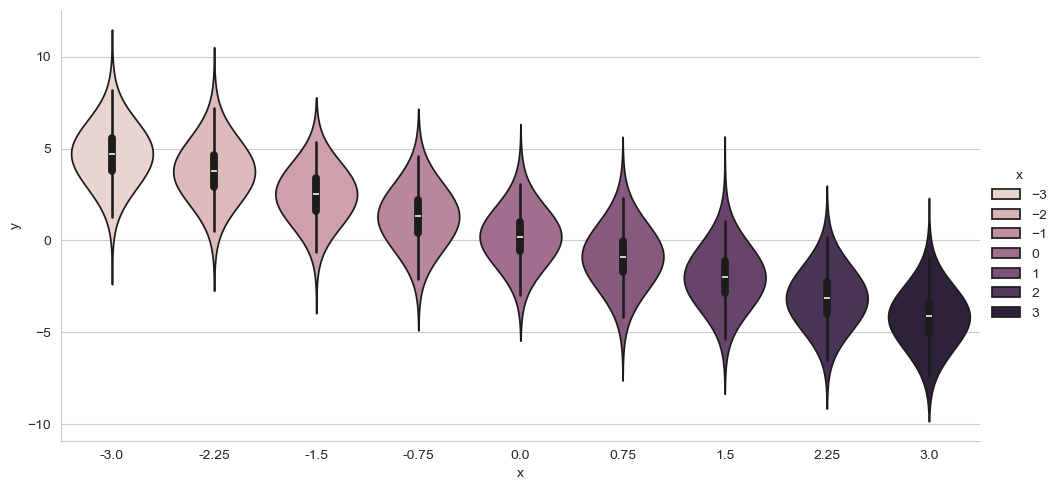

In [217]:
sns.catplot( data = study_500_df, x='x', y='y', kind='violin', hue='x', aspect=2, bw_method=1)
plt.show()

## Why did we do this?

This simple SIMULATION example reveals NEARLY all of the assumptions of the LINEAR MODEL for regression!!!

You have learned that the AVERAGE OUTPUT depends on the INPUT!!!

Changing the INPUT CHANGES the AVERAGE OUTPUT (Trend)!!!

The VARIATION around the TREND is **CONSTANT** and does NOT change as the INPUT changes

The OUTPUT is **NORMALLY** distributed around the AVERAGE OUTPUT!!!